# Google Colab Workshop: Real-Time Motion Tracking / 实时运动跟踪工作坊

# Real-Time AI Motion Tracking Workshop / 实时 AI 运动跟踪工作坊

Welcome to this interactive workshop. In this notebook, we will use computer vision and artificial intelligence to track movement and classify objects using your web camera.

欢迎来到这个互动工作坊。在本笔记本中，我们将使用计算机视觉和人工智能，通过您的网络摄像头来跟踪运动并对物体进行分类。

### Learning Objectives / 学习目标:
1. Understand how to connect a web camera to a cloud environment.
   
   了解如何将网络摄像头连接到云环境。
2. Learn the basics of OpenCV for image processing.
   
   学习 OpenCV 图像处理的基础知识。
3. Apply a custom AI model to real-time video.
   
   将自定义 AI 模型应用于实时视频。

### Instructions for Students / 学生说明:
Run each code block one by one. Read the comments carefully. Some parts of the code are empty. You need to fill in the correct missing functions to make the program
work. Look for the "STUDENT TASK" sections.

逐一运行每个代码块。仔细阅读注释。代码的某些部分是空的。您需要填写正确的缺失函数以使程序运行。请寻找“STUDENT TASK”（学生任务）部分。

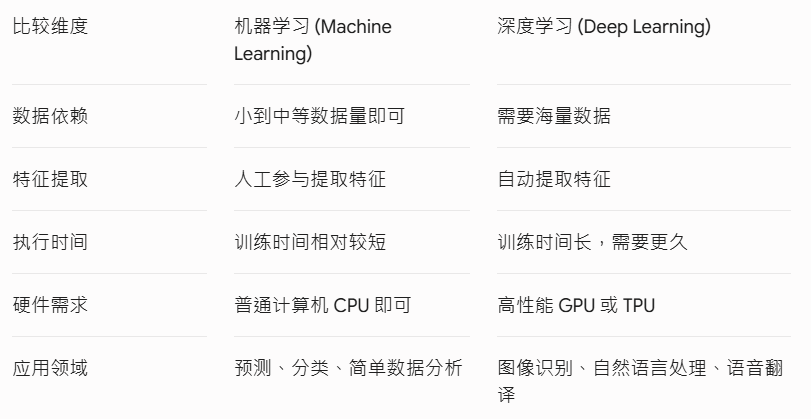

### Part 1: Webcam Setup & Single Frame Capture / 第一部分：摄像头设置与单帧捕获

Description / 说明：

This section imports the necessary libraries, sets up the JavaScript interface to access your webcam, and tests the connection by taking a single photograph.

此部分导入必要的库，设置 JavaScript 接口以访问您的网络摄像头，并通过拍摄单张照片来测试连接。

In [ ]:
# Import necessary libraries
# 导入必要的库
import cv2
import numpy as np
from IPython.display import display, Javascript
from google.colab.output import eval_js
from google.colab.patches import cv2_imshow
from base64 import b64decode

def take_photo(filename='photo.jpg', quality=0.8):
    """
    Open web camera, capture one frame, and return it as an image file.
    打开网络摄像头，捕获一帧，并将其作为图像文件返回。
    """
    js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture Frame (点击拍照)';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))

    # Decode the image data into a format OpenCV can read
    # 将图像数据解码为 OpenCV 可以读取的格式
    binary = b64decode(data.split(',')[1])
    image_bytes = np.frombuffer(binary, dtype=np.uint8)
    img = cv2.imdecode(image_bytes, flags=cv2.IMREAD_COLOR)
    return img

try:
    print("Opening web camera stream... / 正在打开网络摄像头流...")
    frame = take_photo()
    print("Frame captured successfully! / 成功捕获图像！")

    # ==========================================
    # STUDENT TASK 1 / 学生任务 1
    # Display the image using the custom Colab function.
    # 使用自定义的 Colab 函数显示图像。
    # Hint: Use cv2_imshow
    # ==========================================
    _______(frame)

except Exception as err:
    print("Error / 错误:", str(err))

### Part 2: Real-Time Motion Tracking / 第二部分：实时运动跟踪


Description / 说明：

This section establishes a continuous video stream. It uses OpenCV to compare the current frame with the previous one. If a significant difference is detected, the algorithm identifies it as motion and draws a green bounding box around the moving object.

此部分建立连续的视频流。它使用 OpenCV 将当前帧与前一帧进行比较。如果检测到显著差异，算法会将其识别为运动，并在移动的物体周围绘制一个绿色的边界框。

In [ ]:
# ==========================================
# CELL 1: SETUP AND HELPER FUNCTIONS
# 单元格 1：设置与辅助函数
# INSTRUCTION: Just run this cell. / 说明：只需运行此单元格。
# ==========================================

# Import libraries for real-time streaming / 导入实时流媒体所需的库
import cv2
import numpy as np
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode, b64encode
import PIL.Image
import io

def js_to_image(js_reply):
    """
    Converts JavaScript base64 image data to an OpenCV image.
    将 JavaScript 的 base64 图像数据转换为 OpenCV 图像。
    """
    image_bytes = b64decode(js_reply.split(',')[1])
    jpg_as_np = np.frombuffer(image_bytes, dtype=np.uint8)
    img = cv2.imdecode(jpg_as_np, flags=1)
    return img

def overlay_to_bytes(overlay_array):
    """
    Converts the OpenCV drawing array back to base64 for the browser overlay.
    将 OpenCV 绘图数组转换回 base64，以便在浏览器上叠加显示。
    """
    overlay_PIL = PIL.Image.fromarray(overlay_array, 'RGBA')
    iobuf = io.BytesIO()
    overlay_PIL.save(iobuf, format='png')
    overlay_bytes = 'data:image/png;base64,{}'.format((str(b64encode(iobuf.getvalue()), 'utf-8')))
    return overlay_bytes

def start_video_stream():
    """
    Injects JavaScript to start a live video stream in Colab.
    注入 JavaScript 以在 Colab 中启动实时视频流。
    """
    js = Javascript('''
    var video;
    var div = null;
    var stream;
    var captureCanvas;
    var imgElement;
    var labelElement;
    var pendingResolve = null;
    var shutdown = false;

    function removeDom() {
       stream.getVideoTracks()[0].stop();
       video.remove();
       div.remove();
       video = null; div = null; stream = null;
       imgElement = null; captureCanvas = null; labelElement = null;
    }

    function onAnimationFrame() {
      if (!shutdown) { window.requestAnimationFrame(onAnimationFrame); }
      if (pendingResolve) {
        var result = "";
        if (!shutdown) {
          captureCanvas.getContext('2d').drawImage(video, 0, 0, 640, 480);
          result = captureCanvas.toDataURL('image/jpeg', 0.8)
        }
        var lp = pendingResolve;
        pendingResolve = null;
        lp(result);
      }
    }

    async function createDom() {
      if (div !== null) { return stream; }
      div = document.createElement('div');
      div.style.border = '2px solid black';
      div.style.padding = '3px';
      div.style.width = '100%';
      div.style.maxWidth = '640px';
      document.body.appendChild(div);

      const modelOut = document.createElement('div');
      modelOut.innerHTML = "Status (状态):";
      labelElement = document.createElement('span');
      labelElement.innerText = 'Starting... (启动中...)';
      labelElement.style.fontWeight = 'bold';
      modelOut.appendChild(labelElement);
      div.appendChild(modelOut);

      video = document.createElement('video');
      video.style.display = 'block';
      video.width = div.clientWidth - 6;
      video.setAttribute('playsinline', '');
      // Click video to stop / 点击视频停止
      video.onclick = () => { shutdown = true; };
      stream = await navigator.mediaDevices.getUserMedia({video: { facingMode: "user"}});
      div.appendChild(video);

      imgElement = document.createElement('img');
      imgElement.style.position = 'absolute';
      imgElement.style.zIndex = 1;
      imgElement.onclick = () => { shutdown = true; };
      div.appendChild(imgElement);

      const instruction = document.createElement('div');
      instruction.innerHTML = 'Click here or on the video to stop the stream (点击此处或视频以停止流)';
      div.appendChild(instruction);
      instruction.onclick = () => { shutdown = true; };

      video.srcObject = stream;
      await video.play();

      captureCanvas = document.createElement('canvas');
      captureCanvas.width = 640;
      captureCanvas.height = 480;
      window.requestAnimationFrame(onAnimationFrame);

      return stream;
    }

    async function stream_frame(label, imgData) {
      if (shutdown) {
        removeDom();
        shutdown = false;
        return '';
      }
      var preCreate = Date.now();
      stream = await createDom();
      var preShow = Date.now();
      if (label != "") { labelElement.innerHTML = label; }
      if (imgData != "") {
        var videoRect = video.getClientRects()[0];
        imgElement.style.top = videoRect.top + "px";
        imgElement.style.left = videoRect.left + "px";
        imgElement.style.width = videoRect.width + "px";
        imgElement.style.height = videoRect.height + "px";
        imgElement.src = imgData;
      }
      var preCapture = Date.now();
      var result = await new Promise(function(resolve, reject) { pendingResolve = resolve; });
      shutdown = false;
      return {'create': preShow - preCreate, 'show': preCapture - preShow, 'capture': Date.now() - preCapture, 'img': result};
    }
    ''')
    display(js)

print("Setup complete! Move to the next cell. / 设置完成！请移动到下一个单元格。")

In [ ]:
# ==========================================
# CELL 2: MOTION TRACKING EXERCISE
# 单元格 2：运动跟踪练习
# INSTRUCTION: Fill in the blanks (_____) to make it work!
# 说明：填空 (_____) 以使其运行！
# ==========================================

# Start the video stream / 启动视频流
start_video_stream()

label_html = 'OpenCV Motion Tracking Active (OpenCV 运动跟踪已激活)'
overlay_data = ''

# We need to store the previous frame to compare it with the new frame
# 我们需要保存上一帧，以便与新帧进行比较
previous_frame = None

while True:
    js_reply = eval_js('stream_frame("{}", "{}")'.format(label_html, overlay_data))
    if not js_reply:
        break

    # Get the current frame / 获取当前帧
    img = js_to_image(js_reply["img"])

    # ==========================================
    # STUDENT TASK 1 / 学生任务 1
    # Convert the image to grayscale to simplify calculations.
    # 将图像转换为灰度图像以简化计算。
    # Hint: Use cvtColor
    # ==========================================
    gray = cv2._____(img, cv2.COLOR_BGR2GRAY)

    # Apply a blur to remove small background noise
    # 应用模糊处理以消除较小的背景噪点
    gray = cv2.GaussianBlur(gray, (21, 21), 0)

    # If this is the very first frame, save it and skip to the next loop
    # 如果这是第一帧，保存它并跳到下一个循环
    if previous_frame is None:
        previous_frame = gray
        continue

    # ==========================================
    # STUDENT TASK 2 / 学生任务 2
    # Calculate the absolute difference between current and previous frame.
    # 计算当前帧和上一帧之间的绝对差异。
    # Hint: Use absdiff
    # ==========================================
    frame_difference = cv2._____(previous_frame, gray)

    # ==========================================
    # STUDENT TASK 3 / 学生任务 3
    # Apply a threshold to turn moving objects pure white and background black.
    # 应用阈值，将移动的物体变成纯白色，背景变成黑色。
    # Hint: Use threshold
    # ==========================================
    thresh = cv2._____(frame_difference, 25, 255, cv2.THRESH_BINARY)[1]

    # Expand the white areas slightly to group objects together
    # 稍微扩展白色区域，将相邻的物体组合在一起
    thresh = cv2.dilate(thresh, None, iterations=2)

    # Find the outlines (contours) of the moving objects
    # 查找移动物体的轮廓（contours）
    contours, _ = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Create a blank transparent image for drawing the boxes
    # 创建一个空白的透明图像，用于绘制边框
    overlay = np.zeros([480, 640, 4], dtype=np.uint8)

    # Draw a bounding box around any contour that is large enough
    # 为足够大的轮廓绘制边界框
    for contour in contours:
        # Ignore very small movements (like changes in lighting)
        # 忽略非常小的移动（例如光线变化）
        if cv2.contourArea(contour) < 500:
            continue

        # Get the coordinates for the bounding box
        # 获取边界框的坐标
        (x, y, w, h) = cv2.boundingRect(contour)

        # ==========================================
        # STUDENT TASK 4 / 学生任务 4
        # Draw a green rectangle on the transparent overlay.
        # 在透明叠加层上绘制绿色矩形。
        # Hint: Use rectangle
        # ==========================================
        # Color format is (Blue, Green, Red, Alpha). (0, 255, 0, 255) is green.
        cv2._____(overlay, (x, y), (x + w, y + h), (0, 255, 0, 255), 3)

    # Update the previous frame for the next loop comparison
    # 更新上一帧，以便进行下一次循环比较
    previous_frame = gray

    # Send the transparent drawing back to the web browser
    # 将包含边框的透明绘图发送回 Web 浏览器进行显示
    overlay_data = overlay_to_bytes(overlay)

print("Stream stopped securely. / 视频流已安全停止。")

### Live Webcam: Skeleton-Initialized Tracking / 实时网络摄像头：骨架初始化的跟踪

Description / 说明：

This code uses your webcam. It starts in Detection Mode (searching for a human skeleton). Once it finds you, it calculates a bounding box, switches to Tracking Mode (using OpenCV CSRT), and stops searching for skeletons to save processing power. If it loses you, it switches back to Detection Mode.

此代码使用您的网络摄像头。它从检测模式（寻找人体骨架）开始。一旦找到您，它会计算一个边界框，切换到跟踪模式（使用 OpenCV CSRT），并停止搜索骨架以节省处理能力。如果它丢失了您的目标，它会切换回检测模式。

# Human Skeleton Tracking / 人体骨架跟踪

In this section, we will use an AI model to detect 33 key points on the human body. We will write code to draw dots on these points and connect them with lines to create a skeleton.

在这一部分，我们将使用 AI 模型来检测人体上的 33 个关键点。我们将编写代码在这些点上画圆点，并用线将它们连接起来，形成一个骨架。

### Instructions / 说明:
Read the code below. Find the `STUDENT TASK` sections and fill in the missing OpenCV functions (`_____`).

阅读下面的代码。找到 `STUDENT TASK`（学生任务）部分，并填写缺失的 OpenCV 函数（`_____`）。

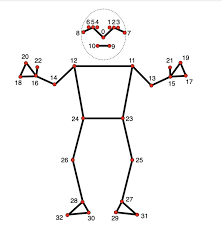

Step 1: Download the Model (New Cell) / 下载模型（新单元格）

In [ ]:
# Download the MediaPipe Pose Lite model / 下载 MediaPipe 姿态轻量级模型
!wget -O pose_landmarker.task -q https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_lite/float16/1/pose_landmarker_lite.task
!pip install mediapipe opencv-contrib-python

In [ ]:
# --- SKELETON POSE TRACKING WEBCAM OVERLAY / 骨架姿态跟踪网络摄像头叠加层 ---

import cv2
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from google.colab.output import eval_js

# 1. Hardcode Skeleton Connections / 硬编码骨架连接图
# We define which dots connect to form the skeleton.
# 我们定义哪些点连接以形成骨架。
POSE_CONNECTIONS = [
    (0, 1), (1, 2), (2, 3), (3, 7), (0, 4), (4, 5), (5, 6), (6, 8), (9, 10),
    (11, 12), (11, 13), (13, 15), (15, 17), (15, 19), (15, 21), (17, 19),
    (12, 14), (14, 16), (16, 18), (16, 20), (16, 22), (18, 20), (11, 23),
    (12, 24), (23, 24), (23, 25), (24, 26), (25, 27), (26, 28), (27, 29),
    (28, 30), (29, 31), (30, 32), (27, 31), (28, 32)
]

# 2. Initialize Tasks API for Pose / 初始化姿态 Tasks API
print("Loading Skeleton Model... / 正在加载骨架模型...")
base_options = python.BaseOptions(model_asset_path='pose_landmarker.task')
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.IMAGE,
    num_poses=1 # Track one person / 跟踪一个人
)
pose_detector = vision.PoseLandmarker.create_from_options(options)

# 3. Start Webcam / 启动网络摄像头
start_video_stream()

label_html = 'Skeleton AI'
overlay_data = ''

while True:
    js_reply = eval_js('stream_frame("{}", "{}")'.format(label_html, overlay_data))
    if not js_reply: break

    img = js_to_image(js_reply["img"])
    h, w = img.shape[:2]

    # Create a blank transparent canvas / 创建空白透明画布
    overlay = np.zeros([h, w, 4], dtype=np.uint8)

    # ==========================================
    # STUDENT TASK 1 / 学生任务 1
    # Convert image color from BGR to RGB. MediaPipe needs RGB color.
    # 将图像颜色从 BGR 转换为 RGB。MediaPipe 需要 RGB 颜色。
    # Hint: Use cvtColor
    # ==========================================
    img_rgb = cv2._____(img, cv2.COLOR_BGR2RGB)

    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
    detection_result = pose_detector.detect(mp_image)

    # 4. Draw Skeleton Landmarks / 绘制骨架特征点
    if detection_result.pose_landmarks:
        for pose_landmarks in detection_result.pose_landmarks:

            # Step A: Save all the point coordinates / 步骤 A：保存所有点的坐标
            points = []
            for landmark in pose_landmarks:
                x = int(landmark.x * w)
                y = int(landmark.y * h)
                points.append((x, y))

                # ==========================================
                # STUDENT TASK 2 / 学生任务 2
                # Draw a circle for each joint (Yellow Dots).
                # 为每个关节画一个圆（黄点）。
                # Hint: Use circle
                # ==========================================
                cv2._____(overlay, (x, y), 5, (0, 255, 255, 255), -1)

            # Step B: Draw the bones connecting the joints / 步骤 B：绘制连接关节的骨骼
            for connection in POSE_CONNECTIONS:
                start_idx = connection[0]
                end_idx = connection[1]

                # Make sure the points exist / 确保点存在
                if start_idx < len(points) and end_idx < len(points):
                    start_point = points[start_idx]
                    end_point = points[end_idx]

                    # ==========================================
                    # STUDENT TASK 3 / 学生任务 3
                    # Draw a line to connect the joints (Green Lines).
                    # 画一条线连接关节（绿线）。
                    # Hint: Use line
                    # ==========================================
                    cv2._____(overlay, start_point, end_point, (0, 255, 0, 255), 3)

        # ==========================================
        # STUDENT TASK 4 / 学生任务 4
        # Put text on the screen to show success.
        # 在屏幕上放置文字以显示成功。
        # Hint: Use putText
        # ==========================================
        cv2._____(overlay, 'Skeleton Detected!', (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0, 255), 2)
    else:
        cv2.putText(overlay, 'Stand in frame...', (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255, 255), 2)

    # Send the transparent drawing back to the browser / 将透明绘图发送回浏览器
    overlay_data = overlay_to_bytes(overlay)

print("Stream stopped.")

# Face Landmark Tracking / 面部特征点跟踪

In this section, we will use the AI to map the human face. The model can detect exactly 468 points (landmarks) on your face in real-time, such as your eyes, nose, and lips.

在这一部分，我们将使用 AI 来映射人脸。该模型可以实时检测您脸上的准确 468 个点（特征点），例如您的眼睛、鼻子和嘴唇。

### Instructions / 说明:
1. Run the first code block to download the Face AI model.
   
   运行第一个代码块以下载面部 AI 模型。
2. Read the main code below. Find the `STUDENT TASK` sections and fill in the missing OpenCV functions (`_____`) to make the face tracker work.
   
   阅读下面的主代码。找到 `STUDENT TASK`（学生任务）部分，并填写缺失的 OpenCV 函数（`_____`），使面部跟踪器正常工作。

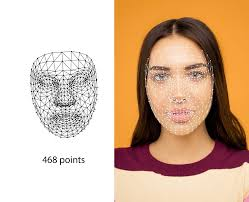

In [ ]:
# Download the MediaPipe Face Landmarker model / 下载 MediaPipe 面部特征点模型
!wget -O face_landmarker.task -q https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task

In [ ]:
# --- FACE DOT TRACKING WEBCAM OVERLAY / 面部点跟踪网络摄像头叠加层 ---
# INSTRUCTION: Fill in the blanks (_____) to make it work!
# 说明：填空 (_____) 以使其运行！

import cv2
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from google.colab.output import eval_js

# 1. Initialize Face AI Model / 初始化面部 AI 模型
print("Loading Face AI Model... / 正在加载面部 AI 模型...")
base_options = python.BaseOptions(model_asset_path='face_landmarker.task')
options = vision.FaceLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.IMAGE,
    num_faces=1 # Track one face / 跟踪一张脸
)
face_detector = vision.FaceLandmarker.create_from_options(options)

# 2. Start the Webcam Stream / 启动网络摄像头流
# Make sure start_video_stream() was run in previous cells!
# 确保在前面的单元格中已运行 start_video_stream()！
start_video_stream()

label_html = 'Face Dot Tracking'
overlay_data = ''

while True:
    # Get frame from browser / 从浏览器获取帧
    js_reply = eval_js('stream_frame("{}", "{}")'.format(label_html, overlay_data))
    if not js_reply:
        break

    img = js_to_image(js_reply["img"])
    h, w = img.shape[:2]

    # Create a blank transparent image for drawing / 创建一个空白的透明图像用于绘图
    overlay = np.zeros([480, 640, 4], dtype=np.uint8)

    # ==========================================
    # STUDENT TASK 1 / 学生任务 1
    # Convert image color from BGR to RGB.
    # 将图像颜色从 BGR 转换为 RGB。
    # Hint: Use cvtColor
    # ==========================================
    img_rgb = cv2._____(img, cv2.COLOR_BGR2RGB)

    # Process image with AI / 使用 AI 处理图像
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
    detection_result = face_detector.detect(mp_image)

    # 3. Draw the Face Dots / 绘制面部点
    if detection_result.face_landmarks:
        for face_landmarks in detection_result.face_landmarks:

            # Loop through all 468 points on the face / 循环遍历脸部的所有 468 个点
            for landmark in face_landmarks:
                # Calculate the exact X and Y pixel coordinates / 计算精确的 X 和 Y 像素坐标
                x = int(landmark.x * w)
                y = int(landmark.y * h)

                # ==========================================
                # STUDENT TASK 2 / 学生任务 2
                # Draw a dot for every point on the face.
                # 为脸上的每个点画一个圆点。
                # Hint: Use circle
                # ==========================================
                # Format: image, center(x,y), radius, color(B,G,R,Alpha), thickness (-1 means solid)
                # 格式：图像, 中心点(x,y), 半径, 颜色(蓝,绿,红,透明度), 粗细 (-1 表示实心)
                cv2._____(overlay, (x, y), 1, (255, 255, 0, 255), -1)

        # ==========================================
        # STUDENT TASK 3 / 学生任务 3
        # Put text on the screen to show success.
        # 在屏幕上放置文字以显示成功。
        # Hint: Use putText
        # ==========================================
        cv2._____(overlay, 'Face Tracked!', (20, 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0, 255), 2)
    else:
        cv2.putText(overlay, 'Looking for face...', (20, 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255, 255), 2)

    # Send the transparent drawing back to the web browser / 将透明绘图发送回 Web 浏览器
    overlay_data = overlay_to_bytes(overlay)

print("Stream stopped securely. / 视频流已安全停止。")

# Hand Landmark Tracking / 手部特征点跟踪

In this section, we will use the AI to map the human hand. The model can detect exactly 21 key points (landmarks) on your hand in real-time, such as your fingertips, knuckles, and wrist.

在这一部分，我们将使用 AI 来映射人手。该模型可以实时检测您手上的准确 21 个关键点（特征点），例如您的指尖、指关节和手腕。

### Instructions / 说明:
1. Run the first code block to download the Hand AI model.
   
   运行第一个代码块以下载手部 AI 模型。
2. Read the main code below. Find the `STUDENT TASK` sections and fill in the missing OpenCV functions (`_____`) to make the hand tracker work.
   
   阅读下面的主代码。找到 `STUDENT TASK`（学生任务）部分，并填写缺失的 OpenCV 函数（`_____`），使手部跟踪器正常工作。

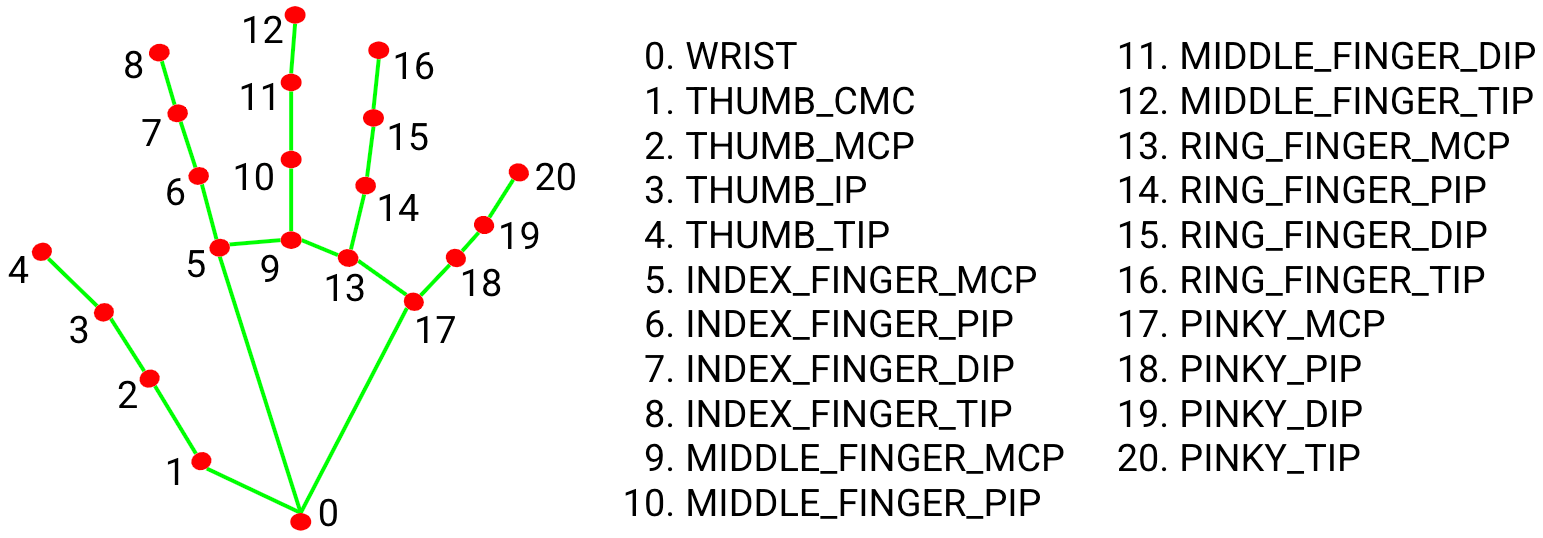

In [ ]:
# Download Hand Landmarker models / 下载手部特征点模型
!wget -O hand_landmarker.task -q https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task


In [ ]:
# --- HAND TRACKING WEBCAM OVERLAY / 手部跟踪网络摄像头叠加层 ---
# INSTRUCTION: Fill in the blanks (_____) to make it work!
# 说明：填空 (_____) 以使其运行！

import cv2
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from google.colab.output import eval_js

# 1. Hardcode Hand Connections / 硬编码手部连接图
# We manually define which dots connect to form the hand.
# 我们手动定义哪些点连接以形成手部。
HAND_CONNECTIONS = [
    (0, 1), (1, 2), (2, 3), (3, 4),         # Thumb / 大拇指
    (0, 5), (5, 6), (6, 7), (7, 8),         # Index finger / 食指
    (5, 9), (9, 10), (10, 11), (11, 12),    # Middle finger / 中指
    (9, 13), (13, 14), (14, 15), (15, 16),  # Ring finger / 无名指
    (13, 17), (0, 17), (17, 18), (18, 19), (19, 20) # Pinky / 小指
]

# 2. Initialize Tasks API for Hands / 初始化手部 Tasks API
print("Loading Hand Model... / 正在加载手部模型...")
base_options = python.BaseOptions(model_asset_path='hand_landmarker.task')
options = vision.HandLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.IMAGE,
    num_hands=2 # Can track up to 2 hands at once / 可同时跟踪最多 2 只手
)
hand_detector = vision.HandLandmarker.create_from_options(options)

# 3. Start Webcam / 启动网络摄像头
# Make sure start_video_stream() was run in previous cells!
# 确保在前面的单元格中已运行 start_video_stream()！
start_video_stream()

label_html = 'Hand Tracking AI'
overlay_data = ''

while True:
    # Get frame from browser / 从浏览器获取帧
    js_reply = eval_js('stream_frame("{}", "{}")'.format(label_html, overlay_data))
    if not js_reply: break

    img = js_to_image(js_reply["img"])
    h, w = img.shape[:2]

    # Create a blank transparent canvas / 创建空白透明画布
    overlay = np.zeros([h, w, 4], dtype=np.uint8)

    # ==========================================
    # STUDENT TASK 1 / 学生任务 1
    # Convert image color from BGR to RGB.
    # 将图像颜色从 BGR 转换为 RGB。
    # Hint: Use cvtColor
    # ==========================================
    img_rgb = cv2._____(img, cv2.COLOR_BGR2RGB)

    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
    detection_result = hand_detector.detect(mp_image)

    # 4. Draw Hand Landmarks Manually / 手动绘制手部特征点
    if detection_result.hand_landmarks:
        for hand_landmarks in detection_result.hand_landmarks:

            # Step A: Save all 21 point coordinates / 步骤 A：保存所有 21 个点的坐标
            points = []
            for landmark in hand_landmarks:
                x = int(landmark.x * w)
                y = int(landmark.y * h)
                points.append((x, y))

                # ==========================================
                # STUDENT TASK 2 / 学生任务 2
                # Draw a dot for every joint on the hand (Red Dots).
                # 为手上的每个关节画一个圆点（红点）。
                # Hint: Use circle
                # ==========================================
                cv2._____(overlay, (x, y), 5, (0, 0, 255, 255), -1)

            # Step B: Draw the bones connecting the joints / 步骤 B：绘制连接关节的骨骼
            for connection in HAND_CONNECTIONS:
                start_idx = connection[0]
                end_idx = connection[1]

                # Make sure the points exist / 确保点存在
                if start_idx < len(points) and end_idx < len(points):
                    start_point = points[start_idx]
                    end_point = points[end_idx]

                    # ==========================================
                    # STUDENT TASK 3 / 学生任务 3
                    # Draw a line to connect the joints (Cyan Lines).
                    # 画一条线连接关节（青色线）。
                    # Hint: Use line
                    # ==========================================
                    cv2._____(overlay, start_point, end_point, (255, 255, 0, 255), 3)

        # ==========================================
        # STUDENT TASK 4 / 学生任务 4
        # Put text on the screen to show success.
        # 在屏幕上放置文字以显示成功。
        # Hint: Use putText
        # ==========================================
        cv2._____(overlay, 'Hands Detected!', (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0, 255), 2)
    else:
        cv2.putText(overlay, 'Show your hands...', (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255, 255), 2)

    # Send the transparent drawing back to the browser / 将透明绘图发送回浏览器
    overlay_data = overlay_to_bytes(overlay)

print("Stream stopped.")

# Custom AI Classification (Teachable Machine) / 自定义 AI 分类

In this final section, we will load your own custom AI model trained using Google Teachable Machine. The AI will look at your web camera and classify what it sees in real-time.

在最后这一部分，我们将加载您使用 Google Teachable Machine 训练的自定义 AI 模型。AI 将查看您的网络摄像头并实时分类它所看到的内容。

### Instructions / 说明:
1. Make sure you have uploaded `keras_model.h5` and `labels.txt` to the Colab files section.
   
   确保您已将 `keras_model.h5` 和 `labels.txt` 上传到 Colab 的文件区域。
2. Run the code cell below. Find the `STUDENT TASK` sections and fill in the missing functions (`_____`) to make the AI work.
   
   运行下面的代码单元格。找到 `STUDENT TASK`（学生任务）部分，并填写缺失的函数（`_____`）以使 AI 正常工作。

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!pip install tf-keras

In [ ]:
# --- CUSTOM AI CLASSIFICATION WEBCAM OVERLAY / 自定义 AI 分类网络摄像头叠加层 ---
# INSTRUCTION: Fill in the blanks (_____) to make it work!
# 说明：填空 (_____) 以使其运行！

# Ensure tf_keras is installed / 确保已安装 tf_keras
# !pip install tf-keras

import tf_keras
import cv2
import numpy as np
from google.colab.output import eval_js

# Disable scientific notation for clarity
# 禁用科学计数法以保持数字清晰
np.set_printoptions(suppress=True)

print("Loading Teachable Machine model... / 正在加载 Teachable Machine 模型...")

# Load the model using the dedicated legacy library
# 使用专用的旧版库加载模型
model = tf_keras.models.load_model("************************", compile=False)

# Load the labels
# 加载标签
class_names = open("**********************", "r").readlines()

# Start the JavaScript Webcam
# 启动 JavaScript 网络摄像头
start_video_stream()

label_html = 'Teachable Machine AI'
overlay_data = ''

while True:
    # Grab the web camera image from the browser
    # 从浏览器获取网络摄像头的图像
    js_reply = eval_js('stream_frame("{}", "{}")'.format(label_html, overlay_data))
    if not js_reply:
        break

    # Convert JS response to OpenCV Image
    # 将 JS 响应转换为 OpenCV 图像
    img = js_to_image(js_reply["img"])
    h, w = img.shape[:2]

    # Create a blank transparent canvas for our text
    # 创建一个空白的透明画布用于绘制文字
    overlay = np.zeros([h, w, 4], dtype=np.uint8)

    # ==========================================
    # STUDENT TASK 1 / 学生任务 1
    # Resize a copy of the image. Teachable Machine requires exactly 224x224 pixels.
    # 调整图像副本的大小。Teachable Machine 需要精确的 224x224 像素。
    # Hint: Use resize
    # ==========================================
    model_image = cv2._____(img, (224, 224), interpolation=cv2.INTER_AREA)

    # Make the image a numpy array and reshape it to the model's input shape
    # 将图像转换为 numpy 数组并重塑为模型的输入形状
    model_image = np.asarray(model_image, dtype=np.float32).reshape(1, 224, 224, 3)

    # Normalize the image array to match training data
    # 归一化图像数组以匹配训练数据
    model_image = (model_image / 127.5) - 1

    # Get the prediction from the model
    # 从模型获取预测结果
    prediction = model.predict(model_image, verbose=0)

    # ==========================================
    # STUDENT TASK 2 / 学生任务 2
    # Find the index position of the highest prediction score.
    # 找到最高预测分数的索引位置。
    # Hint: Use argmax
    # ==========================================
    index = np._____(prediction)

    # Clean up the class name and get the score
    # 清理类别名称并获取分数
    class_name = class_names[index].strip()
    confidence_score = prediction[0][index]

    # Format the text to display on the screen
    # 格式化要在屏幕上显示的文本
    # Note: We use [2:] to remove the number at the start of the label
    # 注意：我们使用 [2:] 去除标签开头的数字
    display_text = f"Class: {class_name[2:]} | Conf: {int(confidence_score * 100)}%"

    # ==========================================
    # STUDENT TASK 3 / 学生任务 3
    # Draw the text on the transparent overlay.
    # 在透明叠加层上绘制文本。
    # Hint: Use putText
    # ==========================================
    cv2._____(overlay, display_text, (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0, 255), 2)

    # Send the transparent text layer back to the browser
    # 将透明文本层发送回浏览器
    overlay_data = overlay_to_bytes(overlay)

print("Stream stopped securely. / 视频流已安全停止。")